# MRT disruption explorer

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tunglinn/youbike-analysis/blob/main/notebooks/mrt_youbike_explorer.ipynb)

Pick a date and hour to check for an MRT disruption. The notebook finds comparison days for you, and then compares Taipei MRT station entries and YouBike rentals with them.

**How to use it**
1. Run all cells (**Runtime → Run all** in Colab, or **Run → Run All Cells** in Jupyter). The first run shows the 3 April 2024 Hualien earthquake as an example.
2. In **Step 1**, set the date and hour in the form, then run that cell. It lists the same weekday in the surrounding weeks and flags days that look unusual (holidays, heavy rain).
3. In **Step 2**, choose which days to leave out of the baseline, then run that cell.

In Colab, the inputs show as a form beside each cell. In Jupyter they're ordinary variables at the top of the cell: edit the values in quotes.

The data comes from Taipei Metro's [hourly station counts](https://data.taipei/dataset/detail?id=63f31c7e-7fc3-418b-bd82-b95158755b4d) and Taipei's YouBike 2.0 rental records. Both are published about 4–6 weeks after the month ends, and both only record the hour. The first run for a new month downloads about 300 MB of MRT data and up to 130 MB of YouBike data, so it takes a few minutes. Later runs use the cache.

The non-interactive version, with a worked example, is [`mrt_youbike_disruption.ipynb`](mrt_youbike_disruption.ipynb).

In [1]:
%pip install -q duckdb pyarrow pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


## Setup

Download and analysis functions. You don't need to change anything here.

In [2]:
#@title Setup: download and analysis functions (run this first) { display-mode: "form" }
import csv, io, ssl, urllib.error, urllib.parse, urllib.request, zipfile
from datetime import date, timedelta
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

DATA = Path("../data/cache") if Path("../data").is_dir() else Path("data_cache")
DATA.mkdir(parents=True, exist_ok=True)

MRT_INDEX = ("https://data.taipei/api/dataset/63f31c7e-7fc3-418b-bd82-b95158755b4d/"
             "resource/eb481f58-1238-4cff-8caa-fa7bb20cb4f4/download")
YB_URL = ("https://tcgbusfs.blob.core.windows.net/dotapp/youbike_second_ticket_opendata/"
          "{y}/{y}-{m:02d}/" + urllib.parse.quote("{y}{m:02d}_YouBike2.0票證刷卡資料.zip", safe="{}:_"))

# data.taipei's certificate lacks a Subject Key Identifier, which Python 3.13+ rejects under its
# stricter default checks; keep normal certificate verification but drop that one strict flag.
SSL_CTX = ssl.create_default_context()
SSL_CTX.verify_flags &= ~getattr(ssl, "VERIFY_X509_STRICT", 0)

def urlopen(url, method="GET", timeout=120):
    req = urllib.request.Request(url, method=method, headers={"User-Agent": "youbike-analysis-notebook"})
    return urllib.request.urlopen(req, timeout=timeout, context=SSL_CTX)

def fetch(url, dest):
    with urlopen(url) as r, open(dest, "wb") as f:
        while chunk := r.read(1 << 20):
            f.write(chunk)

_mrt_index = None
def mrt_index():
    """{(year, month): csv url} for every published MRT month."""
    global _mrt_index
    if _mrt_index is None:
        with urlopen(MRT_INDEX) as r:
            rows = list(csv.reader(io.StringIO(r.read().decode("utf-8-sig"))))
        _mrt_index = {(int(r[1]), int(r[2])): r[-1] for r in rows[1:] if r[1].isdigit()}
    return _mrt_index

def mrt_available(y, m):
    return (DATA / f"mrt_entries_{y}{m:02d}.parquet").exists() or (y, m) in mrt_index()

def youbike_available(y, m):
    if (DATA / f"youbike_{y}{m:02d}.parquet").exists():
        return True
    try:
        with urlopen(YB_URL.format(y=y, m=m), method="HEAD", timeout=30):
            return True
    except urllib.error.HTTPError:
        return False

def mrt_month(y, m, log=print):
    """Hourly entries per station: columns d, h, o (entry station), n."""
    out = DATA / f"mrt_entries_{y}{m:02d}.parquet"
    if out.exists():
        return out
    tmp = DATA / f"mrt_{y}{m:02d}.csv"
    log(f"Downloading MRT {y}-{m:02d} (about 300 MB)…")
    fetch(mrt_index()[(y, m)], tmp)
    # columns: date, hour, entry station, exit station, riders (by position, header is Chinese)
    duckdb.sql(f"""copy (select #1::date d, #2::int h, #3 o, sum(#5::int) n
                 from read_csv('{tmp}', all_varchar=true) group by all) to '{out}'""")
    tmp.unlink()
    return out

def youbike_month(y, m, log=print):
    """Hourly rentals per station pair: columns d, h, rent_station, return_station, n."""
    out = DATA / f"youbike_{y}{m:02d}.parquet"
    if out.exists():
        return out
    zp, tmp = DATA / f"yb_{y}{m:02d}.zip", DATA / f"yb_{y}{m:02d}.csv"
    log(f"Downloading YouBike {y}-{m:02d}…")
    fetch(YB_URL.format(y=y, m=m), zp)
    with zipfile.ZipFile(zp) as z, z.open(z.infolist()[0]) as src, open(tmp, "wb") as dst:
        while chunk := src.read(1 << 20):
            dst.write(chunk)
    zp.unlink()
    # some months ship without a header row, so read by position and drop a header if present;
    # strict_mode=false copes with files whose header ends in CRLF but rows end in LF (e.g. 2021-10)
    has_header = tmp.open(encoding="utf-8", errors="replace").readline().startswith("rent_time")
    duckdb.sql(f"""copy (select cast(#1 as timestamp)::date d, hour(cast(#1 as timestamp)) h,
                   #2 rent_station, #4 return_station, count(*) n
                 from read_csv('{tmp}', delim=',', header={str(has_header).lower()},
                               all_varchar=true, ignore_errors=true, strict_mode=false)
                 group by all) to '{out}'""")
    tmp.unlink()
    return out

LINES = {
    "Brown (BR)": "動物園 木柵 萬芳社區 萬芳醫院 辛亥 麟光 六張犁 科技大樓 中山國中 松山機場 大直 劍南路 西湖 港墘 文德 內湖 大湖公園 葫洲 東湖 南港軟體園區",
    "Red (R)": "象山 台北101/世貿 信義安和 大安森林公園 台大醫院 雙連 圓山 劍潭 士林 芝山 明德 石牌 唭哩岸 奇岩 北投 新北投 復興崗 忠義 關渡 竹圍 紅樹林 淡水",
    "Green (G)": "松山 南京三民 台北小巨蛋 小南門 台電大樓 公館 萬隆 景美 七張 新店區公所 新店 小碧潭",
    "Orange (O)": "南勢角 永安市場 頂溪 行天宮 中山國小 大橋頭站 台北橋 菜寮 先嗇宮 新莊 輔大 丹鳳 迴龍 三重國小 三和國中 徐匯中學 三民高中 蘆洲",
    "Blue (BL)": "頂埔 永寧 土城 海山 亞東醫院 府中 江子翠 龍山寺 善導寺 忠孝敦化 國父紀念館 市政府 永春 後山埤 昆陽",
    "Circular (Y)": "十四張 秀朗橋 景平 中和 橋和 中原 板新 Y板橋 幸福 新北產業園區",
}
LINE_OF = pd.DataFrame([(s, k) for k, v in LINES.items() for s in v.split()], columns=["o", "line"])

def _sql_dates(days):
    return ", ".join(f"date '{d}'" for d in days)

def load(days, log=print):
    """Download what's needed and return (connection, has_youbike)."""
    months = sorted({(d.year, d.month) for d in days})
    con = duckdb.connect()
    mrt_files = [str(mrt_month(y, m, log)) for y, m in months]
    con.sql(f"create view mrt as select * from read_parquet({mrt_files})")
    yb_months = [(y, m) for y, m in months if youbike_available(y, m)]
    has_yb = len(yb_months) == len(months)
    if has_yb:
        yb_files = [str(youbike_month(y, m, log)) for y, m in yb_months]
        con.sql(f"create view yb as select * from read_parquet({yb_files})")
    con.register("line_of", LINE_OF)
    return con, has_yb

def find_baseline(event_day, weeks=4, log=print):
    """Same weekday within +-`weeks` weeks (published data only), with daily totals and flags."""
    today = date.today()
    cands = [event_day + timedelta(weeks=k) for k in range(-weeks, weeks + 1) if k != 0]
    cands = [d for d in cands if d < today and mrt_available(d.year, d.month)]
    if not mrt_available(event_day.year, event_day.month):
        raise ValueError(f"MRT data for {event_day:%Y-%m} isn't published yet. "
                         f"Latest month available: {max(mrt_index())[0]}-{max(mrt_index())[1]:02d}.")
    con, has_yb = load([event_day, *cands], log)
    q = f"select d, sum(n) mrt from mrt where d in ({_sql_dates([event_day, *cands])}) group by d"
    t = con.sql(q).df()
    if has_yb:
        t = t.merge(con.sql(q.replace("from mrt", "from yb").replace("mrt from", "youbike from")).df(), on="d", how="left")
    t["d"] = pd.to_datetime(t.d).dt.date
    t = t.sort_values("d").reset_index(drop=True)
    base = t[t.d != event_day]
    t["mrt_pct"] = t.mrt / base.mrt.median()
    if has_yb:
        t["youbike_pct"] = t.youbike / base.youbike.median()
    def flag(r):
        out = []
        if r.d == event_day:
            return "event day"
        if not 0.85 <= r.mrt_pct <= 1.15:
            out.append("MRT unusual (holiday?)")
        if has_yb and not 0.75 <= r.youbike_pct <= 1.25:
            out.append("YouBike unusual (rain?)")
        return ", ".join(out)
    t["flag"] = t.apply(flag, axis=1)
    t["keep"] = (t.d != event_day) & (t.flag == "")
    return t, con, has_yb

def run_analysis(con, has_yb, event_day, hour, window, baseline_days):
    """Hourly comparison, chart, stop estimate, per-line breakdown and YouBike trip mix."""
    days = [event_day, *baseline_days]
    hours = list(range(max(0, hour - window), min(23, hour + window) + 1))
    ev = f"date '{event_day}'"
    def hourly(view):
        return con.sql(f"""
          with t as (select d, h, sum(n) n from {view} where d in ({_sql_dates(days)}) group by all)
          select h, avg(n) filter (where d <> {ev}) "normal", sum(n) filter (where d = {ev}) "event"
          from t group by h order by h""").df().set_index("h")
    hr = hourly("mrt").add_suffix("_mrt")
    if has_yb:
        hr = hr.join(hourly("yb").add_suffix("_yb"))
    hr = hr.reindex(hours)
    hr["pct_mrt"] = hr.event_mrt / hr.normal_mrt
    if has_yb:
        hr["pct_yb"] = hr.event_yb / hr.normal_yb
    # hours with almost no service (e.g. 05:00, before trains start) give meaningless percentages
    quiet = hr.normal_mrt < 1000
    hr.loc[quiet, hr.columns.str.startswith("pct")] = float("nan")
    if quiet.get(hour, True):
        display(HTML(f"<p><b>{hour:02d}:00 has almost no normal MRT service</b>, so there's nothing to compare. "
                     "Pick an hour between 06:00 and 23:00.</p>"))
        return

    display(HTML(f"<h3>{event_day:%a %d %b %Y}, {hour:02d}:00–{hour+1:02d}:00</h3>"
                 f"<p>Baseline: {', '.join(f'{d:%d %b}' for d in baseline_days)}</p>"))
    num = {c: "{:,.0f}" for c in hr.columns if not c.startswith("pct")}
    pct = {c: "{:.0%}" for c in hr.columns if c.startswith("pct")}
    display(hr.style.format(num | pct, na_rep="–").apply(
        lambda r: ["font-weight:bold" if r.name == hour else "" for _ in r], axis=1))

    fig, ax = plt.subplots(figsize=(9, 4.2))
    x = [h + 0.5 for h in hr.index]
    ax.axvspan(hour, hour + 1, color="#efeee9", zorder=0)
    ax.axhline(1, color="#8a8983", lw=1, ls=(0, (4, 4)))
    ax.plot(x, hr.pct_mrt, "-o", color="#2a78d6", lw=2, ms=6, label="MRT station entries")
    if has_yb:
        ax.plot(x, hr.pct_yb, "-o", color="#eb6834", lw=2, ms=6, label="YouBike rentals")
    ax.set_xticks(range(hours[0], hours[-1] + 2))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(hours[0], hours[-1] + 2)])
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.set_ylim(0, max(1.3, hr.filter(like="pct").max().max() + 0.1))
    ax.set_ylabel("share of a normal day, same hour")
    ax.set_title(f"{event_day}: compared with {len(baseline_days)} baseline days (selected hour shaded)", loc="left")
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis="y", color="#efeee9")
    ax.legend(frameon=False, loc="lower right")
    plt.tight_layout(); plt.show()

    missing = hr.normal_mrt[hour] - hr.event_mrt[hour]
    lines = [f"MRT entries {hour:02d}:00–{hour+1:02d}:00: {hr.pct_mrt[hour]:.0%} of normal "
             f"({hr.event_mrt[hour]:,.0f} vs {hr.normal_mrt[hour]:,.0f})."]
    if missing > 0:
        lines.append(f"Missing entries: {missing:,.0f}, about {missing / hr.normal_mrt[hour] * 60:.0f} minutes of a "
                     "full stop (a lower bound, since gates usually stay open).")
    worst = hr.pct_mrt.idxmin()
    if worst != hour:
        lines.append(f"Note: the lowest hour in this window is {worst:02d}:00 ({hr.pct_mrt[worst]:.0%}).")
    if has_yb:
        lines.append(f"YouBike rentals in the same hour: {hr.pct_yb[hour]:.0%} of normal "
                     f"({hr.event_yb[hour] - hr.normal_yb[hour]:+,.0f}).")
    display(HTML("<ul>" + "".join(f"<li>{s}</li>" for s in lines) + "</ul>"))

    st = con.sql(f"""
      with t as (select o, d, sum(n) n from mrt where d in ({_sql_dates(days)}) and h = {hour} group by all)
      select o, avg(n) filter (where d <> {ev}) "normal", sum(n) filter (where d = {ev}) "event" from t group by o""").df()
    st["pct"] = st.event / st.normal
    busy = st[st.normal > 200]
    by_line = st.merge(LINE_OF, on="o").groupby("line")[["normal", "event"]].sum()
    by_line["pct"] = by_line.event / by_line.normal
    display(HTML(f"<h4>By line</h4><p>{(busy.pct < 0.75).sum()} of {len(busy)} busy stations fell below 75% of normal "
                 f"(median station {busy.pct.median():.0%}). If every line drops together it's a network-wide halt; "
                 "if one line drops alone it's a line fault. Transfer stations are left out.</p>"))
    display(by_line.sort_values("pct").style.format({"normal": "{:,.0f}", "event": "{:,.0f}", "pct": "{:.0%}"}))
    worst_st = busy.sort_values("pct").head(10)[["o", "normal", "event", "pct"]].rename(columns={"o": "station"})
    display(HTML("<h4>Most affected busy stations</h4>"))
    display(worst_st.style.format({"normal": "{:,.0f}", "event": "{:,.0f}", "pct": "{:.0%}"}).hide(axis="index"))

    if has_yb:
        mix = con.sql(f"""
          select h, d = {ev} is_event, sum(n) rentals,
                 sum(n) filter (where rent_station like '捷運%') from_mrt,
                 sum(n) filter (where rent_station like '捷運%' and return_station like '捷運%'
                                and rent_station <> return_station) mrt_to_mrt
          from yb where d in ({_sql_dates(days)}) and h in ({", ".join(map(str, hours))}) group by all""").df()
        g = mix.groupby(["h", "is_event"])[["rentals", "from_mrt", "mrt_to_mrt"]].sum().unstack("is_event")
        out = pd.DataFrame({
            "from MRT, baseline": g.from_mrt[False] / g.rentals[False],
            "from MRT, event": g.from_mrt[True] / g.rentals[True],
            "MRT→MRT, baseline": g.mrt_to_mrt[False] / g.rentals[False],
            "MRT→MRT, event": g.mrt_to_mrt[True] / g.rentals[True],
        }).reindex(hours)
        display(HTML("<h4>YouBike trip mix</h4><p>Share of rentals starting at a bike station named after an MRT exit, "
                     "and share running from one MRT station to another. A jump in the selected hour suggests "
                     "MRT riders switched to bikes.</p>"))
        display(out.style.format("{:.1%}", na_rep="–"))
    else:
        display(HTML("<p><b>YouBike data for this month isn't published yet</b>, so only MRT is shown.</p>"))

## Step 1: choose the date and hour

Rerun this cell whenever you change the date or the search range.

In [3]:
#@title Find baseline days
DATE = "2024-04-03"  #@param {type:"date"}
HOUR = "08:00"  #@param ["00:00", "01:00", "05:00", "06:00", "07:00", "08:00", "09:00", "10:00", "11:00", "12:00", "13:00", "14:00", "15:00", "16:00", "17:00", "18:00", "19:00", "20:00", "21:00", "22:00", "23:00"]
HOURS_EITHER_SIDE = 3  #@param {type:"slider", min:1, max:8, step:1}
WEEKS_TO_SEARCH = 4  #@param {type:"slider", min:1, max:8, step:1}

event_day = date.fromisoformat(DATE)
hour = int(HOUR[:2])
try:
    table, con, has_yb = find_baseline(event_day, WEEKS_TO_SEARCH)
except ValueError as e:
    table = None
    print(e)
else:
    flagged = [d for d, f in zip(table.d, table.flag) if f and f != "event day"]
    print(f"{event_day:%A %d %B %Y}, {HOUR}. Found {len(table) - 1} {event_day:%A}s within ±{WEEKS_TO_SEARCH} weeks.")
    print("Days more than 15% off the typical MRT total, or 25% off the typical YouBike total, are flagged.\n")
    cols = {"mrt": "{:,.0f}", "mrt_pct": "{:.0%}", "youbike": "{:,.0f}", "youbike_pct": "{:.0%}"}
    display(table.drop(columns="keep").rename(columns={"d": "date"})
            .style.format({k: v for k, v in cols.items() if k in table}, na_rep="–")
            .apply(lambda r: ["color:#c0392b" if r.flag and r.flag != "event day" else "" for _ in r], axis=1)
            .hide(axis="index"))
    print("Flagged:", ", ".join(map(str, flagged)) if flagged else "none")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Wednesday 03 April 2024, 08:00. Found 8 Wednesdays within ±4 weeks.
Days more than 15% off the typical MRT total, or 25% off the typical YouBike total, are flagged.



date,mrt,youbike,mrt_pct,youbike_pct,flag
2024-03-06,"2,222,679","72,856",101%,57%,YouBike unusual (rain?)
2024-03-13,"2,242,244","131,955",102%,103%,
2024-03-20,"2,239,623","133,936",102%,105%,
2024-03-27,"2,240,851","140,088",102%,109%,
2024-04-03,"1,895,368","141,953",86%,111%,event day
2024-04-10,"2,176,930","124,306",99%,97%,
2024-04-17,"2,185,087","142,386",99%,111%,
2024-04-24,"2,115,885","63,607",96%,50%,YouBike unusual (rain?)
2024-05-01,"1,707,111","96,334",77%,75%,MRT unusual (holiday?)


Flagged: 2024-03-06, 2024-04-24, 2024-05-01


## Step 2: choose the baseline days and run

`LEAVE_OUT` controls which candidate days are dropped from the baseline:
- `flagged` drops the days flagged in Step 1 (the default).
- A list of dates, like `2024-03-06, 2024-04-24`, drops exactly those days.
- `none` keeps every candidate day.

Left out: Wed 06 Mar 2024, Wed 24 Apr 2024, Wed 01 May 2024


,normal_mrt,event_mrt,normal_yb,event_yb,pct_mrt,pct_yb
h,,,,,,
5,33,28,745,968,–,–
6,"32,198","31,599","2,751","3,297",98%,120%
7,"151,193","142,643","8,279","8,748",94%,106%
8,"270,971","78,189","10,237","12,376",29%,121%
9,"149,932","124,823","7,187","8,341",83%,116%
10,"90,941","88,650","5,675","5,313",97%,94%
11,"83,787","77,582","6,086","6,276",93%,103%


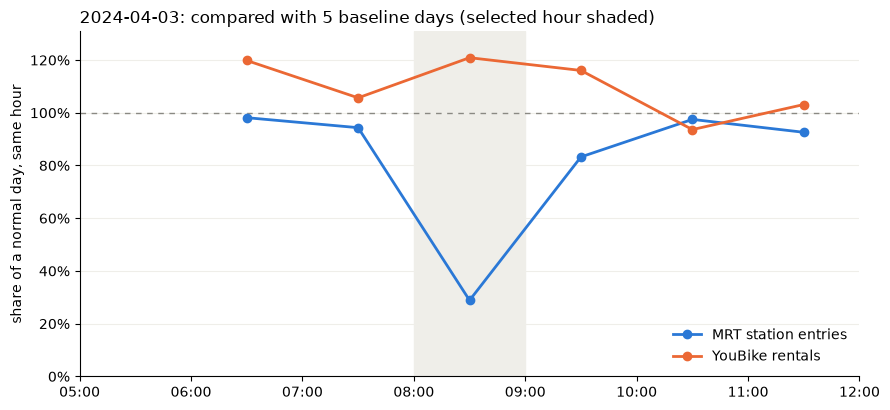

,normal,event,pct
line,,,
Circular (Y),"2,554",438,17%
Orange (O),"57,836","13,882",24%
Green (G),"24,604","6,305",26%
Red (R),"41,829","10,989",26%
Brown (BR),"25,468","7,709",30%
Blue (BL),"45,807","17,509",38%


station,normal,event,pct
大安森林公園,833,80,10%
中和,382,38,10%
景平,354,52,15%
石牌,"3,424",519,15%
景安,"5,936",905,15%
芝山,"3,374",516,15%
十四張,359,55,15%
永安市場,"6,240",981,16%
唭哩岸,"1,578",249,16%
三民高中,"3,399",540,16%


,"from MRT, baseline","from MRT, event","MRT→MRT, baseline","MRT→MRT, event"
h,,,,
5,12.5%,12.4%,2.8%,2.1%
6,19.7%,20.0%,2.1%,2.3%
7,22.0%,22.1%,2.1%,2.3%
8,23.5%,26.1%,2.3%,7.5%
9,21.6%,23.4%,2.3%,4.2%
10,20.6%,21.8%,2.7%,3.1%
11,20.5%,20.4%,3.0%,3.1%


In [4]:
#@title Run the analysis
LEAVE_OUT = "flagged"  #@param {type:"string"}

if table is None:
    print("Step 1 didn't find any data. Fix the date there and rerun it.")
else:
    candidates = [d for d in table.d if d != event_day]
    choice = LEAVE_OUT.strip().lower()
    if choice == "flagged":
        drop = set(flagged)
    elif choice in ("", "none"):
        drop = set()
    else:
        try:
            drop = {date.fromisoformat(s.strip()) for s in LEAVE_OUT.split(",") if s.strip()}
        except ValueError:
            raise ValueError(f'LEAVE_OUT should be "flagged", "none", or dates like 2024-03-06, 2024-04-24 (got "{LEAVE_OUT}")')
        unknown = drop - set(candidates)
        if unknown:
            print("Not candidate days, ignored:", ", ".join(map(str, sorted(unknown))))
    baseline = [d for d in candidates if d not in drop]
    if not baseline:
        print("Every candidate day was left out. Keep at least one.")
    else:
        print("Left out:", ", ".join(f"{d:%a %d %b %Y}" for d in sorted(drop & set(candidates))) or "none")
        run_analysis(con, has_yb, event_day, hour, HOURS_EITHER_SIDE, baseline)

## Notes

- **Hourly data:** a stop shorter than an hour is spread across the hours it touches, so each hour shows a smaller drop than the outage itself. The "minutes of a full stop" figure assumes nobody entered during the stop, so it's a lower bound.
- **Flags are hints:** a flagged day isn't necessarily wrong to use, and an unflagged one isn't guaranteed normal. Check the totals, and leave out days you know were holidays or had events.
- **Venues:** stations next to the Taipei Dome (國父紀念館) and Taipei Arena (台北小巨蛋) swing a lot on concert nights, which can make evening comparisons on the Blue and Green lines misleading.
- **YouBike "MRT station"** means a bike station named after an MRT exit (`捷運…站`). Bike stations near an exit but named differently are missed.